<a href="https://colab.research.google.com/github/shivamkr1353/UCS645/blob/main/LAB8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CUDA available in PyTorch: True
PyTorch GPU: Tesla T4
CuPy GPU: Tesla T4

Problem 1A: CPU vs GPU vector add
N=     1024 CPU=   0.014 ms GPU=   0.008 ms H2D=   1.951 ms speedup=   1.80x
N=    16384 CPU=   0.012 ms GPU=   0.008 ms H2D=   0.178 ms speedup=   1.55x
N=   262144 CPU=   0.155 ms GPU=   0.014 ms H2D=   0.603 ms speedup=  11.34x
N=  4194304 CPU=   5.116 ms GPU=   0.200 ms H2D=  21.982 ms speedup=  25.54x
N= 67108864 CPU= 117.590 ms GPU=   3.071 ms H2D= 368.562 ms speedup=  38.29x


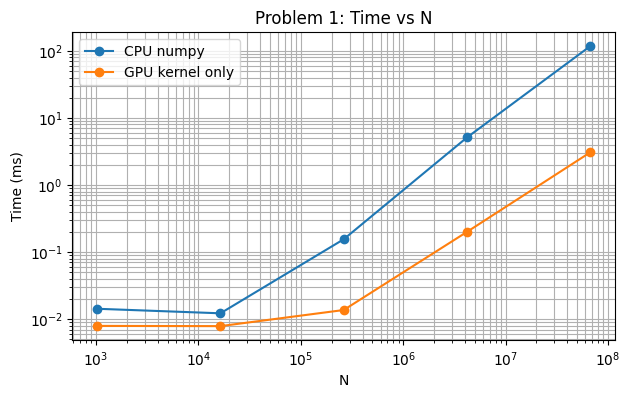


Problem 1A: H2D and D2H bandwidth
   1 MB H2D=   2877.7 MB/s D2H=   2178.6 MB/s
   8 MB H2D=   4722.0 MB/s D2H=   3799.7 MB/s
  64 MB H2D=   4544.5 MB/s D2H=   2560.8 MB/s
 256 MB H2D=   4485.5 MB/s D2H=   2547.0 MB/s
 512 MB H2D=   4500.5 MB/s D2H=   2544.4 MB/s


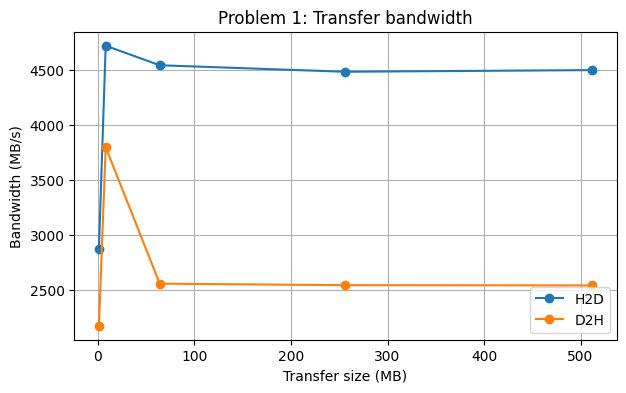

Crossover point: GPU kernel becomes faster around N = 1024
Small N favors CPU because kernel launch and PCIe transfer overhead dominate useful work.

Problem 1B: Launch configuration
threads/block=  64 blocks= 16384 covered= 1048576 all_covered=True time=0.0589 ms
threads/block= 128 blocks=  8192 covered= 1048576 all_covered=True time=0.0571 ms
threads/block= 256 blocks=  4096 covered= 1048576 all_covered=True time=0.0575 ms
threads/block= 512 blocks=  2048 covered= 1048576 all_covered=True time=0.0568 ms
threads/block=1024 blocks=  1024 covered= 1048576 all_covered=True time=0.0595 ms
Multiples of 32 are preferred because a CUDA warp contains 32 threads. Block sizes that are multiples of the warp size avoid partially filled warps, improve scheduler efficiency, and make memory access and reductions easier to reason about.

Problem 1C: Warp divergence
Divergent branch time: 0.7336 ms
Branch-free time:      0.5700 ms
Divergence penalty:    1.29x


In [ ]:
# %% Setup
import os
import sys
import time
import math
import subprocess
import warnings

warnings.filterwarnings("ignore")


def ensure_package(import_name, pip_name):
    try:
        return __import__(import_name)
    except ImportError:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
        return __import__(import_name)


np = ensure_package("numpy", "numpy")
cp = ensure_package("cupy", "cupy-cuda12x")
torch = ensure_package("torch", "torch")
plt = ensure_package("matplotlib.pyplot", "matplotlib")

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

try:
    import torchvision
    import torchvision.transforms as T
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchvision"])
    import torchvision
    import torchvision.transforms as T


def show_gpu():
    print("CUDA available in PyTorch:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("PyTorch GPU:", torch.cuda.get_device_name(0))
    try:
        print("CuPy GPU:", cp.cuda.runtime.getDeviceProperties(0)["name"].decode())
    except Exception as exc:
        print("CuPy GPU check failed:", exc)


def gpu_time_ms(func, warmup=3, repeat=10):
    """Time GPU work with CUDA events. func must launch GPU work."""
    for _ in range(warmup):
        func()
    cp.cuda.Stream.null.synchronize()
    start = cp.cuda.Event()
    end = cp.cuda.Event()
    times = []
    for _ in range(repeat):
        start.record()
        func()
        end.record()
        end.synchronize()
        times.append(cp.cuda.get_elapsed_time(start, end))
    return float(np.mean(times))


def torch_time_ms(func, warmup=3, repeat=10):
    for _ in range(warmup):
        func()
    torch.cuda.synchronize()
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    times = []
    for _ in range(repeat):
        start.record()
        func()
        end.record()
        torch.cuda.synchronize()
        times.append(start.elapsed_time(end))
    return float(np.mean(times))


show_gpu()

# %% Problem 1: GPU Architecture and CUDA Kernel Profiling
problem1_code = r"""
extern "C" __global__
void vector_add(const float* a, const float* b, float* c, int n) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i < n) c[i] = a[i] + b[i];
}

extern "C" __global__
void vector_scale(const float* x, float* y, float alpha, int n) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i < n) y[i] = alpha * x[i];
}

extern "C" __global__
void squared_diff(const float* a, const float* b, float* out, int n) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i < n) {
        float d = a[i] - b[i];
        out[i] = d * d;
    }
}

extern "C" __global__
void divergent_kernel(const float* x, float* y, int n) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i < n) {
        if ((threadIdx.x & 1) == 0) y[i] = x[i] * 2.0f + 1.0f;
        else y[i] = x[i] * 2.0f - 1.0f;
    }
}

extern "C" __global__
void branch_free_kernel(const float* x, float* y, int n) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i < n) {
        float s = 1.0f - 2.0f * (float)(threadIdx.x & 1);
        y[i] = x[i] * 2.0f + s;
    }
}
"""

p1 = cp.RawModule(code=problem1_code)
vector_add = p1.get_function("vector_add")
vector_scale = p1.get_function("vector_scale")
squared_diff = p1.get_function("squared_diff")
divergent_kernel = p1.get_function("divergent_kernel")
branch_free_kernel = p1.get_function("branch_free_kernel")


def run_problem1():
    print("\nProblem 1A: CPU vs GPU vector add")
    sizes = [2**10, 2**14, 2**18, 2**22, 2**26]
    rows = []
    cpu_times = []
    gpu_times = []
    h2d_times = []

    for n in sizes:
        a_np = np.random.rand(n).astype(np.float32)
        b_np = np.random.rand(n).astype(np.float32)

        t0 = time.perf_counter()
        c_np = a_np + b_np
        cpu_ms = (time.perf_counter() - t0) * 1000

        start = cp.cuda.Event()
        end = cp.cuda.Event()
        start.record()
        a = cp.asarray(a_np)
        b = cp.asarray(b_np)
        end.record()
        end.synchronize()
        h2d_ms = cp.cuda.get_elapsed_time(start, end)

        c = cp.empty_like(a)
        blocks = ((n + 255) // 256,)
        gpu_ms = gpu_time_ms(lambda: vector_add(blocks, (256,), (a, b, c, n)), repeat=20)
        assert np.allclose(cp.asnumpy(c), c_np, atol=1e-5)

        speedup = cpu_ms / gpu_ms
        rows.append((n, cpu_ms, gpu_ms, h2d_ms, speedup))
        cpu_times.append(cpu_ms)
        gpu_times.append(gpu_ms)
        h2d_times.append(h2d_ms)
        print(f"N={n:>9} CPU={cpu_ms:8.3f} ms GPU={gpu_ms:8.3f} ms H2D={h2d_ms:8.3f} ms speedup={speedup:7.2f}x")

    plt.figure(figsize=(7, 4))
    plt.loglog(sizes, cpu_times, "o-", label="CPU numpy")
    plt.loglog(sizes, gpu_times, "o-", label="GPU kernel only")
    plt.xlabel("N")
    plt.ylabel("Time (ms)")
    plt.title("Problem 1: Time vs N")
    plt.grid(True, which="both")
    plt.legend()
    plt.show()

    print("\nProblem 1A: H2D and D2H bandwidth")
    transfer_mb = [1, 8, 64, 256, 512]
    h2d_bw = []
    d2h_bw = []
    for mb in transfer_mb:
        n = mb * 1024 * 1024 // 4
        host = np.random.rand(n).astype(np.float32)
        dev = cp.empty(n, dtype=cp.float32)
        h2d_ms = gpu_time_ms(lambda: dev.set(host), repeat=5)
        d2h_ms = gpu_time_ms(lambda: dev.get(), repeat=5)
        h2d = mb / (h2d_ms / 1000)
        d2h = mb / (d2h_ms / 1000)
        h2d_bw.append(h2d)
        d2h_bw.append(d2h)
        print(f"{mb:>4} MB H2D={h2d:9.1f} MB/s D2H={d2h:9.1f} MB/s")

    plt.figure(figsize=(7, 4))
    plt.plot(transfer_mb, h2d_bw, "o-", label="H2D")
    plt.plot(transfer_mb, d2h_bw, "o-", label="D2H")
    plt.xlabel("Transfer size (MB)")
    plt.ylabel("Bandwidth (MB/s)")
    plt.title("Problem 1: Transfer bandwidth")
    plt.grid(True)
    plt.legend()
    plt.show()

    faster = [r for r in rows if r[2] < r[1]]
    if faster:
        print("Crossover point: GPU kernel becomes faster around N =", faster[0][0])
    print("Small N favors CPU because kernel launch and PCIe transfer overhead dominate useful work.")

    print("\nProblem 1B: Launch configuration")
    n = 2**20
    a = cp.random.rand(n, dtype=cp.float32)
    b = cp.random.rand(n, dtype=cp.float32)
    c = cp.empty_like(a)
    for tpb in [64, 128, 256, 512, 1024]:
        blocks = (n + tpb - 1) // tpb
        covered = blocks * tpb
        ms = gpu_time_ms(lambda tpb=tpb, blocks=blocks: vector_add((blocks,), (tpb,), (a, b, c, n)), repeat=30)
        print(f"threads/block={tpb:4d} blocks={blocks:6d} covered={covered:8d} all_covered={covered >= n} time={ms:.4f} ms")
    print("Multiples of 32 are preferred because a CUDA warp contains 32 threads. Block sizes that are multiples of the warp size avoid partially filled warps, improve scheduler efficiency, and make memory access and reductions easier to reason about.")

    print("\nProblem 1C: Warp divergence")
    n = 2**24
    x = cp.random.rand(n, dtype=cp.float32)
    y = cp.empty_like(x)
    blocks = ((n + 255) // 256,)
    div_ms = gpu_time_ms(lambda: divergent_kernel(blocks, (256,), (x, y, n)), repeat=30)
    bf_ms = gpu_time_ms(lambda: branch_free_kernel(blocks, (256,), (x, y, n)), repeat=30)
    print(f"Divergent branch time: {div_ms:.4f} ms")
    print(f"Branch-free time:      {bf_ms:.4f} ms")
    print(f"Divergence penalty:    {div_ms / bf_ms:.2f}x")


run_problem1()

In [ ]:
# %% Problem 2: Parallel Reduction and Shared Memory Optimization
problem2_code = r"""
extern "C" __global__
void sequential_sum(const float* x, float* out, int n) {
    float s = 0.0f;
    for (int i = 0; i < n; ++i) s += x[i];
    out[0] = s;
}

extern "C" __global__
void shared_sum(const float* x, float* partial, int n) {
    extern __shared__ float sdata[];
    unsigned int tid = threadIdx.x;
    unsigned int i = blockIdx.x * (blockDim.x * 2) + threadIdx.x;
    float sum = 0.0f;
    if (i < n) sum += x[i];
    if (i + blockDim.x < n) sum += x[i + blockDim.x];
    sdata[tid] = sum;
    __syncthreads();
    for (unsigned int stride = blockDim.x / 2; stride > 0; stride >>= 1) {
        if (tid < stride) sdata[tid] += sdata[tid + stride];
        __syncthreads();
    }
    if (tid == 0) partial[blockIdx.x] = sdata[0];
}

__inline__ __device__
float warp_reduce_sum(float val) {
    for (int offset = 16; offset > 0; offset /= 2)
        val += __shfl_down_sync(0xffffffff, val, offset);
    return val;
}

extern "C" __global__
void warp_sum(const float* x, float* partial, int n) {
    float sum = 0.0f;
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = blockDim.x * gridDim.x;
    for (int i = idx; i < n; i += stride) sum += x[i];
    sum = warp_reduce_sum(sum);
    __shared__ float warp_sums[32];
    int lane = threadIdx.x & 31;
    int wid = threadIdx.x >> 5;
    if (lane == 0) warp_sums[wid] = sum;
    __syncthreads();
    sum = (threadIdx.x < blockDim.x / 32) ? warp_sums[lane] : 0.0f;
    if (wid == 0) sum = warp_reduce_sum(sum);
    if (threadIdx.x == 0) partial[blockIdx.x] = sum;
}

extern "C" __global__
void bank_conflict_demo(float* out, int stride, int iters) {
    __shared__ float tile[1024];
    int tid = threadIdx.x;
    float acc = 0.0f;
    for (int i = 0; i < iters; ++i) {
        int idx = (tid * stride) & 1023;
        tile[idx] = (float)tid;
        __syncthreads();
        acc += tile[idx];
        __syncthreads();
    }
    out[blockIdx.x * blockDim.x + tid] = acc;
}

extern "C" __global__
void unpadded_2d(float* out, int iters) {
    __shared__ float tile[16][16];
    int tx = threadIdx.x;
    int ty = threadIdx.y;
    float acc = 0.0f;
    for (int k = 0; k < iters; ++k) {
        tile[ty][tx] = (float)(tx + ty);
        __syncthreads();
        acc += tile[tx][ty];
        __syncthreads();
    }
    out[blockIdx.x * 256 + ty * 16 + tx] = acc;
}

extern "C" __global__
void padded_2d(float* out, int iters) {
    __shared__ float tile[16][17];
    int tx = threadIdx.x;
    int ty = threadIdx.y;
    float acc = 0.0f;
    for (int k = 0; k < iters; ++k) {
        tile[ty][tx] = (float)(tx + ty);
        __syncthreads();
        acc += tile[tx][ty];
        __syncthreads();
    }
    out[blockIdx.x * 256 + ty * 16 + tx] = acc;
}

extern "C" __global__
void hist_private_shared(const unsigned char* data, unsigned int* partial, int n) {
    __shared__ unsigned int hist[256];
    int tid = threadIdx.x;
    for (int i = tid; i < 256; i += blockDim.x) hist[i] = 0;
    __syncthreads();
    int idx = blockIdx.x * blockDim.x + tid;
    int stride = blockDim.x * gridDim.x;
    for (int i = idx; i < n; i += stride) atomicAdd(&hist[data[i]], 1);
    __syncthreads();
    for (int i = tid; i < 256; i += blockDim.x) {
        partial[blockIdx.x * 256 + i] = hist[i];
    }
}

extern "C" __global__
void merge_hist(const unsigned int* partial, unsigned int* out, int blocks) {
    int bin = blockIdx.x * blockDim.x + threadIdx.x;
    if (bin < 256) {
        unsigned int s = 0;
        for (int b = 0; b < blocks; ++b) s += partial[b * 256 + bin];
        out[bin] = s;
    }
}
"""

p2 = cp.RawModule(code=problem2_code)
sequential_sum = p2.get_function("sequential_sum")
shared_sum = p2.get_function("shared_sum")
warp_sum = p2.get_function("warp_sum")
bank_conflict_demo = p2.get_function("bank_conflict_demo")
unpadded_2d = p2.get_function("unpadded_2d")
padded_2d = p2.get_function("padded_2d")
hist_private_shared = p2.get_function("hist_private_shared")
merge_hist = p2.get_function("merge_hist")


def run_problem2():
    print("\nProblem 2A: Reduction strategies")
    n = 2**20
    x = cp.random.rand(n, dtype=cp.float32)
    expected = float(cp.sum(x).get())
    out = cp.zeros(1, dtype=cp.float32)

    seq_ms = gpu_time_ms(lambda: sequential_sum((1,), (1,), (x, out, n)), repeat=5)
    seq_val = float(out.get()[0])

    tpb = 256
    blocks = (n + tpb * 2 - 1) // (tpb * 2)
    partial = cp.zeros(blocks, dtype=cp.float32)
    shmem = tpb * 4
    shared_ms = gpu_time_ms(lambda: shared_sum((blocks,), (tpb,), (x, partial, n), shared_mem=shmem), repeat=20)
    shared_val = float(cp.sum(partial).get())

    blocks2 = min(1024, (n + tpb - 1) // tpb)
    partial2 = cp.zeros(blocks2, dtype=cp.float32)
    warp_ms = gpu_time_ms(lambda: warp_sum((blocks2,), (tpb,), (x, partial2, n)), repeat=20)
    warp_val = float(cp.sum(partial2).get())

    for name, ms, val in [
        ("naive sequential", seq_ms, seq_val),
        ("shared tree", shared_ms, shared_val),
        ("warp shuffle", warp_ms, warp_val),
    ]:
        gbps = (n * 4) / (ms / 1000) / 1e9
        print(f"{name:17s} time={ms * 1000:9.2f} us throughput={gbps:8.2f} GB/s correct={abs(val - expected) < 0.1}")

    print("\nProblem 2B: Bank conflict profiling")
    out_demo = cp.zeros(64 * 256, dtype=cp.float32)
    for stride in [1, 2, 4, 8, 16, 32]:
        ms = gpu_time_ms(lambda stride=stride: bank_conflict_demo((64,), (256,), (out_demo, stride, 1000)), repeat=20)
        print(f"stride={stride:2d} time={ms:.4f} ms")
    print("stride=32 maps many threads to the same shared-memory bank, serializing access. stride=1 spreads consecutive threads across banks.")

    out2d = cp.zeros(64 * 256, dtype=cp.float32)
    unpad_ms = gpu_time_ms(lambda: unpadded_2d((64,), (16, 16), (out2d, 1000)), repeat=20)
    pad_ms = gpu_time_ms(lambda: padded_2d((64,), (16, 16), (out2d, 1000)), repeat=20)
    print(f"2D unpadded tile[16][16]: {unpad_ms:.4f} ms")
    print(f"2D padded   tile[16][17]: {pad_ms:.4f} ms")
    print(f"padding speedup: {unpad_ms / pad_ms:.2f}x")

    print("\nProblem 2C: Shared-memory histogram")
    n = 2**22
    data = cp.random.randint(0, 256, size=n, dtype=cp.uint8)
    blocks = 256
    partial_h = cp.zeros((blocks, 256), dtype=cp.uint32)
    hist = cp.zeros(256, dtype=cp.uint32)
    ms1 = gpu_time_ms(lambda: hist_private_shared((blocks,), (256,), (data, partial_h, n)), repeat=10)
    ms2 = gpu_time_ms(lambda: merge_hist((1,), (256,), (partial_h, hist, blocks)), repeat=10)
    expected_hist = cp.bincount(data.astype(cp.int32), minlength=256).astype(cp.uint32)
    print(f"private shared histogram time: {ms1 + ms2:.4f} ms correct={bool(cp.all(hist == expected_hist).get())}")


run_problem2()


Problem 2A: Reduction strategies
naive sequential  time= 30475.30 us throughput=    0.14 GB/s correct=False
shared tree       time=    28.62 us throughput=  146.56 GB/s correct=True
warp shuffle      time=    15.09 us throughput=  277.90 GB/s correct=True

Problem 2B: Bank conflict profiling
stride= 1 time=0.0735 ms
stride= 2 time=0.1120 ms
stride= 4 time=0.2003 ms
stride= 8 time=0.3768 ms
stride=16 time=0.7260 ms
stride=32 time=1.4269 ms
stride=32 maps many threads to the same shared-memory bank, serializing access. stride=1 spreads consecutive threads across banks.
2D unpadded tile[16][16]: 0.2214 ms
2D padded   tile[16][17]: 0.1110 ms
padding speedup: 2.00x

Problem 2C: Shared-memory histogram
private shared histogram time: 0.0883 ms correct=True



Problem 3A: Activation kernels
sigmoid       time=0.4085 ms bandwidth~=195.84 GB/s correct=True
tanh          time=0.3668 ms bandwidth~=218.11 GB/s correct=True
leaky_relu    time=0.3504 ms bandwidth~=228.33 GB/s correct=True
relu_backward time=0.4442 ms bandwidth~=180.10 GB/s correct=True


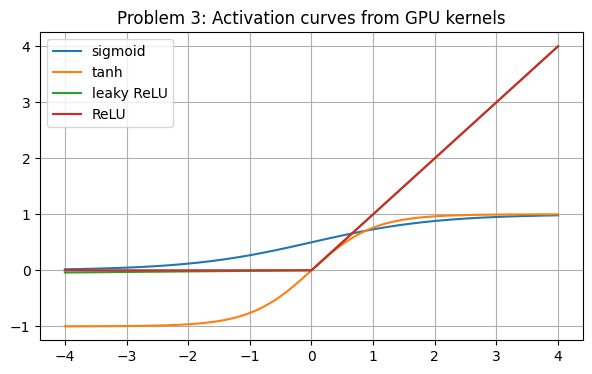


Problem 3B: BCE and cross entropy
BCE mean abs error: 9.588802640791982e-09
CE loss GPU: 2.7407143115997314 PyTorch: 2.7407143115997314
CE grad matches autograd: True

Problem 3C: Adam fused kernel
Adam 100-step match: True


In [ ]:
# %% Problem 3: Custom ML Kernels - Activations, Loss and Backprop
problem3_code = r"""
extern "C" __global__
void sigmoid_kernel(const float* x, float* y, int n) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i < n) y[i] = 1.0f / (1.0f + expf(-x[i]));
}

extern "C" __global__
void tanh_kernel(const float* x, float* y, int n) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i < n) y[i] = tanhf(x[i]);
}

extern "C" __global__
void leaky_relu_kernel(const float* x, float* y, float alpha, int n) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i < n) y[i] = x[i] > 0.0f ? x[i] : alpha * x[i];
}

extern "C" __global__
void relu_backward_kernel(const float* grad_out, const float* x, float* grad_in, int n) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i < n) grad_in[i] = x[i] > 0.0f ? grad_out[i] : 0.0f;
}

extern "C" __global__
void bce_loss_kernel(const float* pred, const float* target, float* loss, int n) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i < n) {
        float p = fminf(fmaxf(pred[i], 1e-7f), 1.0f - 1e-7f);
        loss[i] = -(target[i] * logf(p) + (1.0f - target[i]) * logf(1.0f - p));
    }
}

extern "C" __global__
void cross_entropy_loss_kernel(const float* logits, const int* labels, float* losses, int batch, int classes) {
    int row = blockIdx.x;
    if (row < batch) {
        const float* z = logits + row * classes;
        float maxv = z[0];
        for (int c = 1; c < classes; ++c) maxv = fmaxf(maxv, z[c]);
        float sumexp = 0.0f;
        for (int c = 0; c < classes; ++c) sumexp += expf(z[c] - maxv);
        losses[row] = -z[labels[row]] + maxv + logf(sumexp);
    }
}

extern "C" __global__
void cross_entropy_grad_kernel(const float* logits, const int* labels, float* grad, int batch, int classes) {
    int row = blockIdx.x;
    int c = threadIdx.x;
    if (row < batch && c < classes) {
        const float* z = logits + row * classes;
        float maxv = z[0];
        for (int k = 1; k < classes; ++k) maxv = fmaxf(maxv, z[k]);
        float sumexp = 0.0f;
        for (int k = 0; k < classes; ++k) sumexp += expf(z[k] - maxv);
        float softmax = expf(z[c] - maxv) / sumexp;
        grad[row * classes + c] = (softmax - (c == labels[row] ? 1.0f : 0.0f)) / batch;
    }
}

extern "C" __global__
void adam_kernel(float* param, const float* grad, float* m, float* v,
                 float lr, float beta1, float beta2, float eps,
                 float bias_correction1, float bias_correction2, int n) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i < n) {
        float g = grad[i];
        m[i] = beta1 * m[i] + (1.0f - beta1) * g;
        v[i] = beta2 * v[i] + (1.0f - beta2) * g * g;
        float mhat = m[i] / bias_correction1;
        float vhat = v[i] / bias_correction2;
        param[i] -= lr * mhat / (sqrtf(vhat) + eps);
    }
}
"""

p3 = cp.RawModule(code=problem3_code)
sigmoid_kernel = p3.get_function("sigmoid_kernel")
tanh_kernel = p3.get_function("tanh_kernel")
leaky_relu_kernel = p3.get_function("leaky_relu_kernel")
relu_backward_kernel = p3.get_function("relu_backward_kernel")
bce_loss_kernel = p3.get_function("bce_loss_kernel")
cross_entropy_loss_kernel = p3.get_function("cross_entropy_loss_kernel")
cross_entropy_grad_kernel = p3.get_function("cross_entropy_grad_kernel")
adam_kernel = p3.get_function("adam_kernel")


def run_problem3():
    print("\nProblem 3A: Activation kernels")
    n = 10_000_000
    x = cp.linspace(-4, 4, n, dtype=cp.float32)
    y = cp.empty_like(x)
    grad_out = cp.ones_like(x)
    grad_in = cp.empty_like(x)
    blocks = ((n + 255) // 256,)

    activations = [
        ("sigmoid", lambda: sigmoid_kernel(blocks, (256,), (x, y, n)), lambda z: 1 / (1 + cp.exp(-z))),
        ("tanh", lambda: tanh_kernel(blocks, (256,), (x, y, n)), cp.tanh),
        ("leaky_relu", lambda: leaky_relu_kernel(blocks, (256,), (x, y, np.float32(0.01), n)), lambda z: cp.maximum(z, 0) + 0.01 * cp.minimum(z, 0)),
        ("relu_backward", lambda: relu_backward_kernel(blocks, (256,), (grad_out, x, grad_in, n)), None),
    ]
    for name, launch, ref_fn in activations:
        ms = gpu_time_ms(launch, repeat=20)
        gbps = (n * 2 * 4) / (ms / 1000) / 1e9
        if name == "relu_backward":
            correct = bool(cp.allclose(grad_in, (x > 0).astype(cp.float32), atol=1e-4).get())
        else:
            correct = bool(cp.allclose(y, ref_fn(x), atol=1e-4).get())
        print(f"{name:13s} time={ms:.4f} ms bandwidth~={gbps:.2f} GB/s correct={correct}")

    xs = cp.linspace(-4, 4, 1000, dtype=cp.float32)
    ys = cp.empty_like(xs)
    b = ((xs.size + 255) // 256,)
    curves = {}
    sigmoid_kernel(b, (256,), (xs, ys, xs.size)); curves["sigmoid"] = cp.asnumpy(ys.copy())
    tanh_kernel(b, (256,), (xs, ys, xs.size)); curves["tanh"] = cp.asnumpy(ys.copy())
    leaky_relu_kernel(b, (256,), (xs, ys, np.float32(0.01), xs.size)); curves["leaky ReLU"] = cp.asnumpy(ys.copy())
    xcpu = cp.asnumpy(xs)
    plt.figure(figsize=(7, 4))
    for k, v in curves.items():
        plt.plot(xcpu, v, label=k)
    plt.plot(xcpu, np.maximum(xcpu, 0), label="ReLU")
    plt.title("Problem 3: Activation curves from GPU kernels")
    plt.grid(True)
    plt.legend()
    plt.show()

    print("\nProblem 3B: BCE and cross entropy")
    pred = cp.random.rand(1024, dtype=cp.float32)
    target = cp.random.randint(0, 2, size=1024).astype(cp.float32)
    loss = cp.empty_like(pred)
    bce_loss_kernel(((1024 + 255) // 256,), (256,), (pred, target, loss, 1024))
    torch_bce = F.binary_cross_entropy(torch.tensor(cp.asnumpy(pred)), torch.tensor(cp.asnumpy(target)), reduction="none").numpy()
    print("BCE mean abs error:", float(np.mean(np.abs(cp.asnumpy(loss) - torch_bce))))

    batch, classes = 512, 10
    logits = cp.random.randn(batch, classes).astype(cp.float32)
    labels = cp.random.randint(0, classes, size=batch).astype(cp.int32)
    losses = cp.zeros(batch, dtype=cp.float32)
    grad = cp.zeros((batch, classes), dtype=cp.float32)
    cross_entropy_loss_kernel((batch,), (1,), (logits, labels, losses, batch, classes))
    cross_entropy_grad_kernel((batch,), (classes,), (logits, labels, grad, batch, classes))
    lt = torch.tensor(cp.asnumpy(logits), requires_grad=True)
    yt = torch.tensor(cp.asnumpy(labels), dtype=torch.long)
    ce = F.cross_entropy(lt, yt)
    ce.backward()
    print("CE loss GPU:", float(cp.mean(losses).get()), "PyTorch:", float(ce.detach()))
    print("CE grad matches autograd:", np.allclose(cp.asnumpy(grad), lt.grad.numpy(), atol=1e-4))

    print("\nProblem 3C: Adam fused kernel")
    n = 4096
    lr, beta1, beta2, eps = 1e-3, 0.9, 0.999, 1e-8
    p_cp = cp.random.randn(n).astype(cp.float32)
    p_t = torch.tensor(cp.asnumpy(p_cp), dtype=torch.float32)
    m = cp.zeros(n, dtype=cp.float32)
    v = cp.zeros(n, dtype=cp.float32)
    opt = torch.optim.Adam([p_t], lr=lr, betas=(beta1, beta2), eps=eps)
    for step in range(1, 101):
        g_np = np.random.randn(n).astype(np.float32)
        g_cp = cp.asarray(g_np)
        bc1 = np.float32(1.0 - beta1**step)
        bc2 = np.float32(1.0 - beta2**step)
        adam_kernel(((n + 255) // 256,), (256,), (p_cp, g_cp, m, v, np.float32(lr), np.float32(beta1), np.float32(beta2), np.float32(eps), bc1, bc2, n))
        opt.zero_grad()
        p_t.grad = torch.tensor(g_np)
        opt.step()
    print("Adam 100-step match:", np.allclose(cp.asnumpy(p_cp), p_t.detach().numpy(), atol=2e-5))


run_problem3()


Problem 4A: Tiled GEMM correctness and benchmark
N= 128 naive=   0.033 ms    125.8 GFLOPS | tiled=   0.028 ms    151.0 GFLOPS | cuBLAS=   0.041 ms    103.0 GFLOPS | correct=True
N= 256 naive=   0.165 ms    202.9 GFLOPS | tiled=   0.113 ms    296.1 GFLOPS | cuBLAS=   0.074 ms    453.8 GFLOPS | correct=True
N= 512 naive=   1.152 ms    233.0 GFLOPS | tiled=   0.749 ms    358.4 GFLOPS | cuBLAS=   0.158 ms   1699.0 GFLOPS | correct=True
N=1024 naive=   9.200 ms    233.4 GFLOPS | tiled=   5.748 ms    373.6 GFLOPS | cuBLAS=   0.747 ms   2873.0 GFLOPS | correct=True
N=2048 naive=  37.242 ms    461.3 GFLOPS | tiled=  24.982 ms    687.7 GFLOPS | cuBLAS=   3.315 ms   5182.9 GFLOPS | correct=True


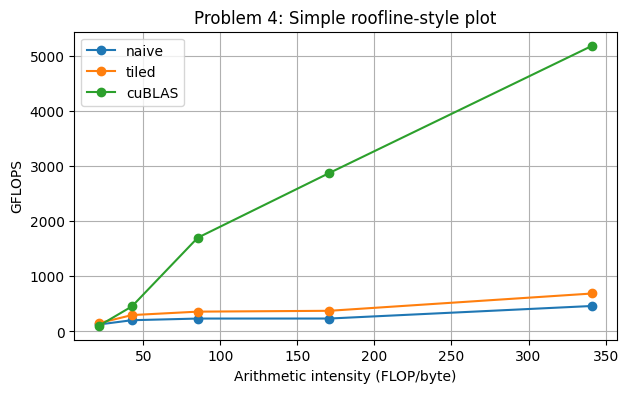

cuBLAS is faster because it uses deep tiling, vectorized/global-memory scheduling, register blocking, Tensor Cores where possible, and many architecture-specific kernels.

Problem 4B: CNN layer benchmarks
Conv2D PyTorch 3x3 same: 0.1318 ms
MaxPool custom:          0.0377 ms | PyTorch: 0.0261 ms
BatchNorm custom:        0.0188 ms | PyTorch: 0.0577 ms


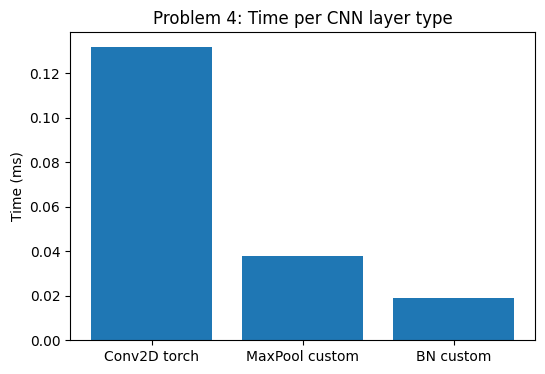


Problem 4C: im2col convolution
im2col time=0.0242 ms GEMM time=0.0595 ms col/input memory overhead=9.00x


In [ ]:
# %% Problem 4: Tiled GEMM vs cuBLAS and CNN Layer Benchmarking
problem4_code = r"""
#define TILE 16

extern "C" __global__
void naive_matmul(const float* A, const float* B, float* C, int M, int K, int N) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < M && col < N) {
        float acc = 0.0f;
        for (int k = 0; k < K; ++k) acc += A[row * K + k] * B[k * N + col];
        C[row * N + col] = acc;
    }
}

extern "C" __global__
void tiled_matmul(const float* A, const float* B, float* C, int M, int K, int N) {
    __shared__ float As[TILE][TILE];
    __shared__ float Bs[TILE][TILE];
    int row = blockIdx.y * TILE + threadIdx.y;
    int col = blockIdx.x * TILE + threadIdx.x;
    float acc = 0.0f;
    for (int t = 0; t < (K + TILE - 1) / TILE; ++t) {
        int a_col = t * TILE + threadIdx.x;
        int b_row = t * TILE + threadIdx.y;
        As[threadIdx.y][threadIdx.x] = (row < M && a_col < K) ? A[row * K + a_col] : 0.0f;
        Bs[threadIdx.y][threadIdx.x] = (b_row < K && col < N) ? B[b_row * N + col] : 0.0f;
        __syncthreads();
        for (int k = 0; k < TILE; ++k) acc += As[threadIdx.y][k] * Bs[k][threadIdx.x];
        __syncthreads();
    }
    if (row < M && col < N) C[row * N + col] = acc;
}

extern "C" __global__
void maxpool2x2(const float* x, float* y, int total, int C, int H, int W) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    int Ho = H / 2;
    int Wo = W / 2;
    if (idx < total) {
        int w = idx % Wo;
        int h = (idx / Wo) % Ho;
        int c = (idx / (Wo * Ho)) % C;
        int n = idx / (Wo * Ho * C);
        int base = ((n * C + c) * H + h * 2) * W + w * 2;
        float m = x[base];
        m = fmaxf(m, x[base + 1]);
        m = fmaxf(m, x[base + W]);
        m = fmaxf(m, x[base + W + 1]);
        y[idx] = m;
    }
}

extern "C" __global__
void batchnorm_inference(const float* x, float* y, const float* gamma, const float* beta,
                         const float* mean, const float* var, float eps,
                         int total, int C, int H, int W) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < total) {
        int c = (idx / (H * W)) % C;
        y[idx] = gamma[c] * (x[idx] - mean[c]) * rsqrtf(var[c] + eps) + beta[c];
    }
}

extern "C" __global__
void im2col_kernel(const float* x, float* col, int Nn, int C, int H, int W, int kH, int kW, int pad, int Hout, int Wout) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    int total = Nn * C * kH * kW * Hout * Wout;
    if (idx < total) {
        int ow = idx % Wout;
        int oh = (idx / Wout) % Hout;
        int kw = (idx / (Wout * Hout)) % kW;
        int kh = (idx / (Wout * Hout * kW)) % kH;
        int c = (idx / (Wout * Hout * kW * kH)) % C;
        int n = idx / (Wout * Hout * kW * kH * C);
        int ih = oh + kh - pad;
        int iw = ow + kw - pad;
        float val = 0.0f;
        if (ih >= 0 && ih < H && iw >= 0 && iw < W) val = x[((n * C + c) * H + ih) * W + iw];
        int row = c * kH * kW + kh * kW + kw;
        int col_idx = n * Hout * Wout + oh * Wout + ow;
        col[row * (Nn * Hout * Wout) + col_idx] = val;
    }
}
"""

p4 = cp.RawModule(code=problem4_code)
naive_matmul = p4.get_function("naive_matmul")
tiled_matmul = p4.get_function("tiled_matmul")
maxpool2x2 = p4.get_function("maxpool2x2")
batchnorm_inference = p4.get_function("batchnorm_inference")
im2col_kernel = p4.get_function("im2col_kernel")


def run_problem4():
    print("\nProblem 4A: Tiled GEMM correctness and benchmark")
    sizes = [128, 256, 512, 1024, 2048]
    rows = []
    for size in sizes:
        A = cp.random.randn(size, size).astype(cp.float32)
        B = cp.random.randn(size, size).astype(cp.float32)
        Cn = cp.empty((size, size), dtype=cp.float32)
        Ct = cp.empty((size, size), dtype=cp.float32)
        block = (16, 16)
        grid = ((size + 15) // 16, (size + 15) // 16)
        naive_ms = gpu_time_ms(lambda: naive_matmul(grid, block, (A, B, Cn, size, size, size)), repeat=5 if size <= 512 else 2)
        tiled_ms = gpu_time_ms(lambda: tiled_matmul(grid, block, (A, B, Ct, size, size, size)), repeat=5 if size <= 512 else 2)
        cublas_ms = gpu_time_ms(lambda: cp.dot(A, B), repeat=10)
        ref = cp.dot(A, B)
        ok = bool(cp.allclose(Ct, ref, rtol=1e-2, atol=1e-2).get())
        flops = 2 * size**3
        rows.append((size, naive_ms, tiled_ms, cublas_ms))
        print(f"N={size:4d} naive={naive_ms:8.3f} ms {flops/(naive_ms/1000)/1e9:8.1f} GFLOPS | tiled={tiled_ms:8.3f} ms {flops/(tiled_ms/1000)/1e9:8.1f} GFLOPS | cuBLAS={cublas_ms:8.3f} ms {flops/(cublas_ms/1000)/1e9:8.1f} GFLOPS | correct={ok}")

    plt.figure(figsize=(7, 4))
    for label, idx in [("naive", 1), ("tiled", 2), ("cuBLAS", 3)]:
        xs = []
        ys = []
        for size, naive_ms, tiled_ms, cublas_ms in rows:
            ms = [None, naive_ms, tiled_ms, cublas_ms][idx]
            intensity = (2 * size**3) / (3 * size**2 * 4)
            gflops = (2 * size**3) / (ms / 1000) / 1e9
            xs.append(intensity)
            ys.append(gflops)
        plt.plot(xs, ys, "o-", label=label)
    plt.xlabel("Arithmetic intensity (FLOP/byte)")
    plt.ylabel("GFLOPS")
    plt.title("Problem 4: Simple roofline-style plot")
    plt.grid(True)
    plt.legend()
    plt.show()

    print("cuBLAS is faster because it uses deep tiling, vectorized/global-memory scheduling, register blocking, Tensor Cores where possible, and many architecture-specific kernels.")

    print("\nProblem 4B: CNN layer benchmarks")
    Nn, C, H, W = 32, 64, 14, 14
    x_cp = cp.random.randn(Nn, C, H, W).astype(cp.float32)
    y_pool = cp.empty((Nn, C, H // 2, W // 2), dtype=cp.float32)
    total_pool = y_pool.size
    pool_ms = gpu_time_ms(lambda: maxpool2x2(((total_pool + 255) // 256,), (256,), (x_cp, y_pool, total_pool, C, H, W)), repeat=30)

    gamma = cp.ones(C, dtype=cp.float32)
    beta = cp.zeros(C, dtype=cp.float32)
    mean = cp.mean(x_cp, axis=(0, 2, 3)).astype(cp.float32)
    var = cp.var(x_cp, axis=(0, 2, 3)).astype(cp.float32)
    y_bn = cp.empty_like(x_cp)
    bn_ms = gpu_time_ms(lambda: batchnorm_inference(((x_cp.size + 255) // 256,), (256,), (x_cp, y_bn, gamma, beta, mean, var, np.float32(1e-5), x_cp.size, C, H, W)), repeat=30)

    x_t = torch.tensor(cp.asnumpy(x_cp), device="cuda")
    w_t = torch.randn(64, 64, 3, 3, device="cuda")
    conv_ms = torch_time_ms(lambda: F.conv2d(x_t, w_t, padding=1), repeat=30)
    pool_t_ms = torch_time_ms(lambda: F.max_pool2d(x_t, 2), repeat=30)
    bn_mod = nn.BatchNorm2d(C).cuda().eval()
    bn_t_ms = torch_time_ms(lambda: bn_mod(x_t), repeat=30)
    print(f"Conv2D PyTorch 3x3 same: {conv_ms:.4f} ms")
    print(f"MaxPool custom:          {pool_ms:.4f} ms | PyTorch: {pool_t_ms:.4f} ms")
    print(f"BatchNorm custom:        {bn_ms:.4f} ms | PyTorch: {bn_t_ms:.4f} ms")

    plt.figure(figsize=(6, 4))
    plt.bar(["Conv2D torch", "MaxPool custom", "BN custom"], [conv_ms, pool_ms, bn_ms])
    plt.ylabel("Time (ms)")
    plt.title("Problem 4: Time per CNN layer type")
    plt.show()

    print("\nProblem 4C: im2col convolution")
    Nn, Cin, H, W = 8, 3, 32, 32
    Cout, kH, kW, pad = 16, 3, 3, 1
    Hout, Wout = H, W
    x = cp.random.randn(Nn, Cin, H, W).astype(cp.float32)
    weight = cp.random.randn(Cout, Cin, kH, kW).astype(cp.float32)
    col = cp.empty((Cin * kH * kW, Nn * Hout * Wout), dtype=cp.float32)
    total = col.size
    im2col_ms = gpu_time_ms(lambda: im2col_kernel(((total + 255) // 256,), (256,), (x, col, Nn, Cin, H, W, kH, kW, pad, Hout, Wout)), repeat=20)
    gemm_ms = gpu_time_ms(lambda: weight.reshape(Cout, -1) @ col, repeat=20)
    memory_overhead = col.nbytes / x.nbytes
    print(f"im2col time={im2col_ms:.4f} ms GEMM time={gemm_ms:.4f} ms col/input memory overhead={memory_overhead:.2f}x")


run_problem4()

In [ ]:
# %% Problem 5: Full MNIST CNN Training - Design, Train and Optimize
class MnistCNN(nn.Module):
    def __init__(self, use_bn=False, dropout=0.0):
        super().__init__()
        self.use_bn = use_bn
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_bn else nn.Identity()
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_bn else nn.Identity()
        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout(dropout)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # [N, 32, 14, 14]
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # [N, 64, 7, 7]
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)


def build_loaders(batch_size=256, augment=False):
    train_tfms = []
    if augment:
        train_tfms += [
            T.RandomRotation(10),
            T.RandomAffine(degrees=0, shear=10),
        ]
    train_tfms += [T.ToTensor()]
    if augment:
        train_tfms += [T.RandomErasing(p=0.1)]
    train_transform = T.Compose(train_tfms)
    test_transform = T.Compose([T.ToTensor()])
    train_ds = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=train_transform)
    test_ds = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=test_transform)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader


def build_optimizer(model, name="adam", lr=1e-3):
    if name == "sgd_momentum":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    return torch.optim.Adam(model.parameters(), lr=lr)


def build_scheduler(optimizer, name=None, epochs=10):
    if name == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    if name == "step":
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.3)
    return None


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        total_loss += float(loss) * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


def train_one_config(name, use_bn=False, dropout=0.0, optimizer_name="adam", scheduler_name=None,
                     augment=False, epochs=5, batch_size=256, amp=False):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_loader, test_loader = build_loaders(batch_size=batch_size, augment=augment)
    model = MnistCNN(use_bn=use_bn, dropout=dropout).to(device)
    optimizer = build_optimizer(model, optimizer_name, lr=1e-3 if optimizer_name == "adam" else 0.05)
    scheduler = build_scheduler(optimizer, scheduler_name, epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=amp)
    history = []
    epochs_to_95 = None
    t_start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        train_correct = 0
        train_total = 0
        train_loss_sum = 0.0
        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=amp):
                logits = model(x)
                loss = F.cross_entropy(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss_sum += float(loss.detach()) * x.size(0)
            train_correct += (logits.detach().argmax(1) == y).sum().item()
            train_total += x.size(0)
        if scheduler is not None:
            scheduler.step()

        test_loss, test_acc = evaluate(model, test_loader, device)
        train_loss = train_loss_sum / train_total
        train_acc = train_correct / train_total
        mem_mb = torch.cuda.max_memory_allocated() / 1024**2 if device == "cuda" else 0
        if epochs_to_95 is None and test_acc >= 0.95:
            epochs_to_95 = epoch
        history.append((epoch, train_loss, train_acc, test_acc, mem_mb))
        print(f"{name:24s} epoch={epoch:02d} train_loss={train_loss:.4f} train_acc={train_acc*100:.2f}% test_acc={test_acc*100:.2f}% mem={mem_mb:.1f} MB")

    elapsed = time.perf_counter() - t_start
    final_acc = history[-1][3]
    return {
        "name": name,
        "model": model,
        "history": history,
        "final_acc": final_acc,
        "epochs_to_95": epochs_to_95,
        "time_s": elapsed,
    }


def benchmark_async_transfer(loader, batches=100):
    if not torch.cuda.is_available():
        print("CUDA not available; skipping stream benchmark.")
        return
    device = "cuda"
    xs = []
    ys = []
    for i, (x, y) in enumerate(loader):
        xs.append(x)
        ys.append(y)
        if i + 1 >= batches:
            break

    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for x, y in zip(xs, ys):
        _ = x.to(device, non_blocking=False)
        _ = y.to(device, non_blocking=False)
    torch.cuda.synchronize()
    sync_s = time.perf_counter() - t0

    stream = torch.cuda.Stream()
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.cuda.stream(stream):
        for x, y in zip(xs, ys):
            _ = x.to(device, non_blocking=True)
            _ = y.to(device, non_blocking=True)
    stream.synchronize()
    async_s = time.perf_counter() - t0
    print(f"100-batch sync transfer:  {sync_s:.4f} s")
    print(f"100-batch async transfer: {async_s:.4f} s")
    print(f"transfer speedup: {sync_s / async_s:.2f}x")


def run_problem5():
    print("\nProblem 5A: Main MNIST CNN training")
    # For the formal assignment, set epochs=10. To smoke-test quickly, set epochs=1.
    main = train_one_config("main_bn_adam_step", use_bn=True, dropout=0.0, optimizer_name="adam",
                            scheduler_name="step", augment=False, epochs=10, batch_size=256, amp=False)

    print("\nProblem 5B: Ablation study, 5 epochs each")
    configs = [
        dict(name="baseline_adam", use_bn=False, dropout=0.0, optimizer_name="adam", scheduler_name=None),
        dict(name="batchnorm_adam", use_bn=True, dropout=0.0, optimizer_name="adam", scheduler_name=None),
        dict(name="dropout_adam", use_bn=False, dropout=0.5, optimizer_name="adam", scheduler_name=None),
        dict(name="sgd_momentum_cosine", use_bn=False, dropout=0.0, optimizer_name="sgd_momentum", scheduler_name="cosine"),
    ]
    results = []
    for cfg in configs:
        results.append(train_one_config(**cfg, augment=False, epochs=5, batch_size=256, amp=False))

    print("\nAblation table")
    print("Configuration             Test Accuracy (%)   Epochs to 95%   Training Time (s)")
    for r in results:
        e95 = r["epochs_to_95"] if r["epochs_to_95"] is not None else "not reached"
        print(f"{r['name']:24s} {r['final_acc']*100:16.2f} {str(e95):>15s} {r['time_s']:18.1f}")

    print("\nProblem 5C: Data augmentation comparison")
    no_aug = train_one_config("no_augmentation", use_bn=True, dropout=0.0, optimizer_name="adam",
                              scheduler_name=None, augment=False, epochs=5, batch_size=256, amp=False)
    aug = train_one_config("with_augmentation", use_bn=True, dropout=0.0, optimizer_name="adam",
                           scheduler_name=None, augment=True, epochs=5, batch_size=256, amp=False)
    print(f"No augmentation final test accuracy:   {no_aug['final_acc']*100:.2f}%")
    print(f"With augmentation final test accuracy: {aug['final_acc']*100:.2f}%")

    print("\nProblem 5D: Bonus AMP and CUDA streams")
    train_loader, _ = build_loaders(batch_size=256, augment=False)
    benchmark_async_transfer(train_loader, batches=100)
    amp_result = train_one_config("amp_training", use_bn=True, dropout=0.0, optimizer_name="adam",
                                  scheduler_name=None, augment=False, epochs=5, batch_size=256, amp=True)
    print(f"AMP final test accuracy: {amp_result['final_acc']*100:.2f}%")

    print("\nProfiler hint:")
    print("Use torch.profiler.profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA]) around a few training steps, then print key_averages().table(sort_by='cuda_time_total', row_limit=10).")


# This full section can take a while in Colab.
# Uncomment the next line when you are ready to train.
run_problem5()




Problem 5A: Main MNIST CNN training


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 354kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.86MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.56MB/s]


main_bn_adam_step        epoch=01 train_loss=0.1661 train_acc=94.97% test_acc=98.44% mem=164.6 MB
main_bn_adam_step        epoch=02 train_loss=0.0464 train_acc=98.58% test_acc=98.50% mem=164.6 MB
main_bn_adam_step        epoch=03 train_loss=0.0343 train_acc=98.95% test_acc=98.73% mem=164.6 MB
main_bn_adam_step        epoch=04 train_loss=0.0253 train_acc=99.18% test_acc=98.96% mem=164.6 MB
main_bn_adam_step        epoch=05 train_loss=0.0199 train_acc=99.36% test_acc=98.95% mem=164.6 MB
main_bn_adam_step        epoch=06 train_loss=0.0089 train_acc=99.76% test_acc=99.24% mem=164.6 MB
main_bn_adam_step        epoch=07 train_loss=0.0064 train_acc=99.84% test_acc=99.32% mem=164.6 MB
main_bn_adam_step        epoch=08 train_loss=0.0054 train_acc=99.89% test_acc=99.16% mem=164.6 MB
main_bn_adam_step        epoch=09 train_loss=0.0045 train_acc=99.91% test_acc=99.24% mem=164.6 MB
main_bn_adam_step        epoch=10 train_loss=0.0042 train_acc=99.92% test_acc=99.23% mem=164.6 MB

Problem 5B: Ablatio